## **1. Import Libraries**

In [2]:
import pandas as pd
import numpy as np
from itertools import combinations
import matplotlib.pyplot as plt

## **2. Load the Dataset**

In [3]:
df = pd.read_csv("reddit_opinion_climate_change.csv")
print("Original dataset shape:", df.shape)
df.head()

Original dataset shape: (1673382, 24)


,comment_id,score,self_text,subreddit,created_time,post_id,author_name,controversiality,ups,downs,...,user_link_karma,user_comment_karma,user_total_karma,post_score,post_self_text,post_title,post_upvote_ratio,post_thumbs_ups,post_total_awards_received,post_created_time
0,olbxvv3,1,"Where is the cement in a solar panel?\n\nYes, ...",energy,2026-05-12 07:54:54,1tad2uu,iqisoverrated,0,1,0,...,1.0,127672.0,127673.0,0,**Sunlight** is renewable. **Wind** is renewab...,A solar panel is not a renewable object. It’s ...,0.11,0,0,2026-05-11 19:06:50
1,olbxuvz,1,fr 🤞,conspiracy,2026-05-12 07:54:39,1tatx9l,Aggressive_Chair1470,0,1,0,...,1.0,16285.0,16286.0,0,"# Prologue: A Ship, A Virus, and a False Sense...",The Quiet Pandemic: Why the MV Hondius Hantavi...,0.43,0,0,2026-05-12 07:08:16
2,olbxto7,1,basically any Antarctic ice wall theory is fun...,conspiracy,2026-05-12 07:54:20,1tas3zb,Aggressive_Chair1470,0,1,0,...,1.0,16285.0,16286.0,1,I'll try and share all i know\n\nThere is the ...,Antarctica,0.55,1,0,2026-05-12 05:31:27
3,olbxsyo,1,I want you to be right.,conspiracy,2026-05-12 07:54:09,1tatx9l,FlyGateIsReal,0,1,0,...,4376.0,1860.0,6236.0,0,"# Prologue: A Ship, A Virus, and a False Sense...",The Quiet Pandemic: Why the MV Hondius Hantavi...,0.43,0,0,2026-05-12 07:08:16
4,olbxhgt,1,"It’s a wonderful find, but let’s be realistic:...",worldnews,2026-05-12 07:51:15,1taspl0,jhon-smith2,0,1,0,...,332.0,235.0,567.0,64,NaN,"A massive 11,000-carat ruby has been unearthed...",0.93,64,0,2026-05-12 06:02:33


We first import the full Kaggle dataset. The original dataset contains **1,673,382 rows and 24 columns**, where each row represents a <font color = red>**Reddit comment-level record**</font> related to climate change discussions.

At this stage, we keep the full dataset before applying any time-window filtering, so that we can first inspect the overall data structure and historical discussion volume.

## **3. Check Column Names**

In [4]:
df.columns.tolist()

['comment_id',
 'score',
 'self_text',
 'subreddit',
 'created_time',
 'post_id',
 'author_name',
 'controversiality',
 'ups',
 'downs',
 'user_is_verified',
 'user_account_created_time',
 'user_awardee_karma',
 'user_awarder_karma',
 'user_link_karma',
 'user_comment_karma',
 'user_total_karma',
 'post_score',
 'post_self_text',
 'post_title',
 'post_upvote_ratio',
 'post_thumbs_ups',
 'post_total_awards_received',
 'post_created_time']

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1673382 entries, 0 to 1673381
Data columns (total 24 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   comment_id                  1673382 non-null  object 
 1   score                       1673382 non-null  int64  
 2   self_text                   1673369 non-null  object 
 3   subreddit                   1673382 non-null  object 
 4   created_time                1673382 non-null  object 
 5   post_id                     1673382 non-null  object 
 6   author_name                 1673382 non-null  object 
 7   controversiality            1673382 non-null  int64  
 8   ups                         1673382 non-null  int64  
 9   downs                       1673382 non-null  int64  
 10  user_is_verified            1673382 non-null  bool   
 11  user_account_created_time   1644296 non-null  object 
 12  user_awardee_karma          1673233 non-null  float64
 1

We check the column names, data types, and non-null counts to understand the dataset structure before cleaning. The dataset contains 24 columns, including variables for network construction, engagement and metadata features, and raw text fields.

The key variables required for general preparation and network construction, including `comment_id`, `subreddit`, `author_name`, and `created_time`, have no missing values in the full dataset. Therefore, we do not remove rows simply because some non-key fields are missing. Missing values in fields such as post text or user metadata will be handled later depending on the specific analysis task.

## **4. Convert Timestamp Columns**

In [6]:
date_cols = ["created_time", "user_account_created_time", "post_created_time"]

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

df[date_cols].head()

,created_time,user_account_created_time,post_created_time
0,2026-05-12 07:54:54,2021-01-30 19:49:31,2026-05-11 19:06:50
1,2026-05-12 07:54:39,2025-10-03 21:03:07,2026-05-12 07:08:16
2,2026-05-12 07:54:20,2025-10-03 21:03:07,2026-05-12 05:31:27
3,2026-05-12 07:54:09,2020-10-08 05:18:26,2026-05-12 07:08:16
4,2026-05-12 07:51:15,2026-01-20 17:16:54,2026-05-12 06:02:33


We convert timestamp columns into datetime format. This allows us to examine discussion trends over time and filter the recent one-year window later.

## **5. Remove Duplicated Comments**

In [7]:
duplicate_comments = df["comment_id"].duplicated().sum()
print("Number of duplicated comment_id in the full dataset:", duplicate_comments)

Number of duplicated comment_id in the full dataset: 0


Since `comment_id` uniquely identifies each Reddit comment, we checked for duplicated comment IDs before filtering the dataset by time. The result shows **0 duplicated comment IDs**, so the full dataset does not contain repeated comment records. This means the later monthly/yearly trend and one-year subset will not be affected by duplicate comments.

## **6. Check Full-Period Date Range**

In [8]:
print("Earliest comment time:", df["created_time"].min())
print("Latest comment time:", df["created_time"].max())

Earliest comment time: 2018-06-01 00:40:15
Latest comment time: 2026-05-12 07:54:54


We check the full-period date range after converting the timestamp column. The dataset covers Reddit comments from **1 June 2018 to 12 May 2026**.

Since the cleaned dataset will later be filtered to the recent one-year window, we first keep the full-period data to examine monthly and yearly comment volume trends. This helps justify why the project focuses on recent climate change discussions.

## <font color = red>**7. Full-Period Monthly Comment Volume**</font>

In [9]:
df_full_time = df.dropna(subset=["created_time"]).copy()

df_full_time["comment_month"] = df_full_time["created_time"].dt.to_period("M").astype(str)
df_full_time["comment_year"] = df_full_time["created_time"].dt.year

monthly_volume_full = (
    df_full_time
    .groupby("comment_month")
    .size()
    .reset_index(name="comment_count")
)

monthly_volume_full.head()

,comment_month,comment_count
0,2018-06,46
1,2018-07,89
2,2018-08,190
3,2018-09,239
4,2018-10,392


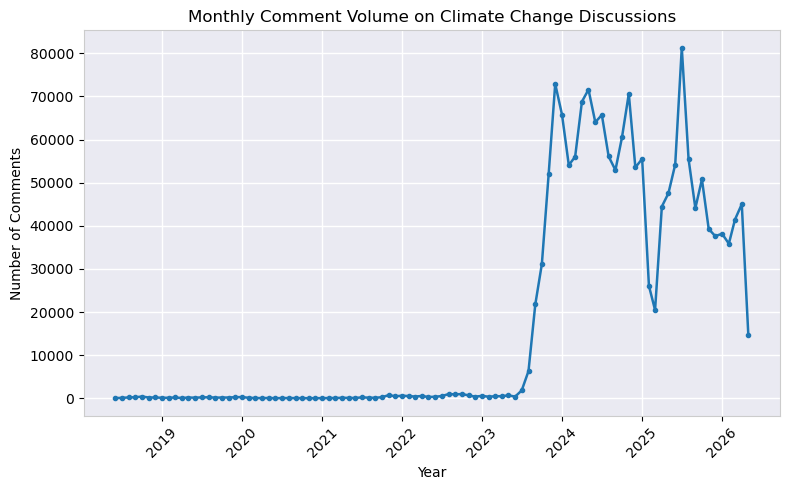

In [11]:
monthly_volume_full["comment_month_dt"] = pd.to_datetime(monthly_volume_full["comment_month"])

fig, ax = plt.subplots(figsize=(8, 5))

# Background color
fig.patch.set_facecolor("white")
ax.set_facecolor("#EAEAF2")  # light grey-blue background

# Original line chart
ax.plot(
    monthly_volume_full["comment_month_dt"],
    monthly_volume_full["comment_count"],
    marker="o",
    markersize=3,
    linewidth=1.8
)

# Labels and title
ax.set_xlabel("Year")
ax.set_ylabel("Number of Comments")
ax.set_title("Monthly Comment Volume on Climate Change Discussions")

# X-axis yearly ticks
year_ticks = pd.date_range(
    start=monthly_volume_full["comment_month_dt"].min(),
    end=monthly_volume_full["comment_month_dt"].max(),
    freq="YS"
)

ax.set_xticks(year_ticks)
ax.set_xticklabels([str(x.year) for x in year_ticks], rotation=45)

# Grid style
ax.grid(True, color="white", linewidth=1)

# Make borders softer
for spine in ax.spines.values():
    spine.set_color("#CCCCCC")

plt.tight_layout()
plt.show()

We examine the monthly comment volume across the full available period before filtering the dataset into the recent one-year window. The monthly trend shows that comment volume was **relatively low from 2018 to 2022, increased sharply from late 2023, and remained much higher during 2024 to 2026.**

The trend also shows noticeable fluctuations in recent years, including a drop around early 2025 and another increase around mid-2025. Therefore, we focus on the <font color = red>**recent one-year window from May 2025 to April 2026**</font> to capture more recent discussion dynamics while keeping the project computationally feasible. This also avoids using the incomplete current month in May 2026.

In [16]:
monthly_volume_full.sort_values("comment_count", ascending=False).head(10)

,comment_month,comment_count,comment_month_dt
85,2025-07,81265,2025-07-01
66,2023-12,72903,2023-12-01
71,2024-05,71591,2024-05-01
77,2024-11,70613,2024-11-01
70,2024-04,68793,2024-04-01
67,2024-01,65769,2024-01-01
73,2024-07,65699,2024-07-01
72,2024-06,64024,2024-06-01
76,2024-10,60534,2024-10-01
74,2024-08,56083,2024-08-01


To better understand the recent fluctuations, we also check the months with the highest comment volume. The peak month is **July 2025**, with **81,265 comments**, followed by several high-volume months in 2023 and 2024. This suggests that the recent period contains much more active climate change discussions than the earlier years.

Since the selected one-year window from **May 2025 to April 2026** includes the highest-volume month and avoids the incomplete current month in May 2026, it is suitable for capturing recent discussion dynamics while keeping the project scope manageable.

In [12]:
# Calculate the share of comments in selected time periods
df_time = df.dropna(subset=["created_time"]).copy()

total_comments = len(df_time)

period_summary = pd.DataFrame({
    "Period": [
        "2018-2022",
        "2023 onwards",
        "Selected window: 2025-05 to 2026-04"
    ],
    "Comment Count": [
        df_time[
            (df_time["created_time"] >= pd.Timestamp("2018-01-01")) &
            (df_time["created_time"] < pd.Timestamp("2023-01-01"))
        ].shape[0],
        
        df_time[
            df_time["created_time"] >= pd.Timestamp("2023-01-01")
        ].shape[0],
        
        df_time[
            (df_time["created_time"] >= pd.Timestamp("2025-05-01")) &
            (df_time["created_time"] <= pd.Timestamp("2026-04-30 23:59:59"))
        ].shape[0]
    ]
})

period_summary["Share of Full Dataset"] = (
    period_summary["Comment Count"] / total_comments
)

period_summary["Share of Full Dataset"] = period_summary["Share of Full Dataset"].apply(lambda x: f"{x:.2%}")

period_summary

,Period,Comment Count,Share of Full Dataset
0,2018-2022,13299,0.79%
1,2023 onwards,1660083,99.21%
2,Selected window: 2025-05 to 2026-04,570641,34.10%


## <font color = red>**8. Full-Period Yearly Comment Volume**</font>

In [13]:
yearly_volume_full = (
    df_full_time
    .groupby("comment_year")
    .size()
    .reset_index(name="comment_count")
)

yearly_volume_full

,comment_year,comment_count
0,2018,1311
1,2019,1912
2,2020,752
3,2021,2278
4,2022,7046
5,2023,188742
6,2024,739632
7,2025,556671
8,2026,175038


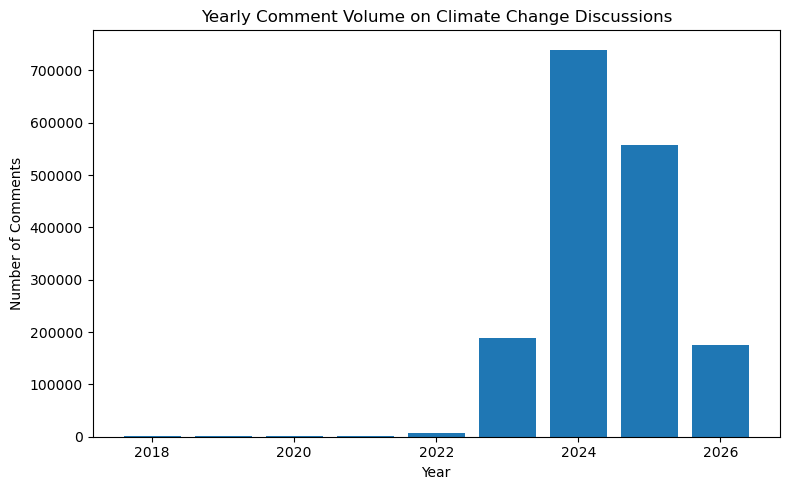

In [14]:
plt.figure(figsize=(8, 5))
plt.bar(yearly_volume_full["comment_year"], yearly_volume_full["comment_count"])
plt.xlabel("Year")
plt.ylabel("Number of Comments")
plt.title("Yearly Comment Volume on Climate Change Discussions")
plt.tight_layout()
plt.show()

We also summarize comment volume by year to provide a high-level view of discussion activity across the full dataset period. The yearly trend shows that most comments are concentrated in recent years, especially 2024 and 2025, while earlier years contain much fewer comments.

However, the 2026 count should be interpreted carefully because the dataset was **accessed on 12 May 2026, meaning 2026 only represents a partial year**. Therefore, the monthly trend is more suitable for explaining the detailed time pattern and supporting our one-year window selection.

## **9. Filter the Recent One-Year Window**

In [19]:
start_date = pd.Timestamp("2025-05-01")
end_date = pd.Timestamp("2026-04-30 23:59:59")

df_1y = df[
    (df["created_time"] >= start_date) &
    (df["created_time"] <= end_date)
].copy()

print("One-year dataset shape:", df_1y.shape)
df_1y.head()

One-year dataset shape: (570641, 24)


,comment_id,score,self_text,subreddit,created_time,post_id,author_name,controversiality,ups,downs,...,user_link_karma,user_comment_karma,user_total_karma,post_score,post_self_text,post_title,post_upvote_ratio,post_thumbs_ups,post_total_awards_received,post_created_time
14573,oj8793w,3,&gt; Sorry baby boy.\n\nI sense some hatred he...,climateskeptics,2026-04-30 23:57:32,1t05dvo,LackmustestTester,0,3,0,...,124059.0,81124.0,205183.0,104,NaN,The Evidence Shows We Are Nowhere Near a Clima...,0.96,104,0,2026-04-30 18:53:47
14574,oj877ch,2,WELL HACKSHUALLY! I don't think the trees were...,climatechange,2026-04-30 23:57:15,1szv0i0,PersevereSwifterSkat,0,2,0,...,189.0,8214.0,8403.0,14,Planting trees has sort of become a icon of cl...,Is Planting trees actually as effective agains...,0.76,14,0,2026-04-30 12:43:30
14575,oj86mg5,1,"You said I'm wrong, but I'm not.\n\nSolar bare...",climatechange,2026-04-30 23:53:55,1szrgl0,WolfedOut,0,1,0,...,836.0,22783.0,23619.0,770,NaN,China’s vast nuclear power sector is now able ...,0.98,770,0,2026-04-30 09:48:28
14576,oj854ey,2,That’s not the only problem.\n\nTrees are a te...,climatechange,2026-04-30 23:45:19,1szv0i0,sevseg_decoder,0,2,0,...,3203.0,268728.0,271931.0,14,Planting trees has sort of become a icon of cl...,Is Planting trees actually as effective agains...,0.76,14,0,2026-04-30 12:43:30
14577,oj84ekd,5,There are similar success stories in re-greeni...,climatechange,2026-04-30 23:41:13,1szv0i0,NNegidius,0,5,0,...,136.0,10894.0,11030.0,14,Planting trees has sort of become a icon of cl...,Is Planting trees actually as effective agains...,0.76,14,0,2026-04-30 12:43:30


We filter the dataset to the recent one-year window from **1 May 2025 to 30 April 2026**, following the project proposal. After filtering, the one-year subset contains **570,641 comment-level records and 24 columns**.

Based on the full-period monthly trend, this window captures a recent period with active climate change discussions while avoiding the incomplete current month in May 2026. It also keeps the data size computationally manageable for later exploratory, network, and text analysis.

## **10. Check Missing Values in the One-Year Dataset**

In [20]:
missing_summary = df_1y.isna().sum().sort_values(ascending=False)
missing_summary

post_self_text                315060
user_account_created_time       5016
user_link_karma                   99
user_total_karma                  99
user_awardee_karma                99
user_awarder_karma                99
user_comment_karma                99
self_text                          4
controversiality                   0
author_name                        0
post_id                            0
created_time                       0
subreddit                          0
score                              0
comment_id                         0
user_is_verified                   0
downs                              0
ups                                0
post_score                         0
post_title                         0
post_upvote_ratio                  0
post_thumbs_ups                    0
post_total_awards_received         0
post_created_time                  0
dtype: int64

We check missing values in the one-year dataset to understand data completeness after filtering. The key variables required for general preparation and network construction, including `comment_id`, `subreddit`, `post_id`, `author_name`, and `created_time`, have no missing values.

The column with the most missing values is `post_self_text`, with 315,060 missing records. We do not remove these rows because many Reddit posts may not contain body text, such as link posts or title-only posts. These records are still valid for comment-level analysis, subreddit-level analysis, engagement analysis, and network construction. For later text analysis, `post_self_text` will only be used as additional context when available, while `post_title` and comment `self_text` remain available for interpretation.

## **11. Clean the One-Year Dataset**

In [21]:
invalid_authors = ["[deleted]", "[removed]", "AutoModerator", "automoderator"]

invalid_author_counts = (
    df_1y[df_1y["author_name"].isin(invalid_authors)]
    ["author_name"]
    .value_counts()
)

invalid_author_counts

author_name
[deleted]    1135
Name: count, dtype: int64

In [22]:
invalid_author_total = df_1y["author_name"].isin(invalid_authors).sum()
invalid_author_share = invalid_author_total / len(df_1y)

print("Number of invalid or automated author records:", invalid_author_total)
print(f"Share of invalid or automated author records: {invalid_author_share:.2%}")

Number of invalid or automated author records: 1135
Share of invalid or automated author records: 0.20%


In [23]:
df_clean = df_1y.copy()
# Remove deleted, removed, or automated users
invalid_authors = ["[deleted]", "[removed]", "AutoModerator", "automoderator"]
df_clean = df_clean[~df_clean["author_name"].isin(invalid_authors)]

print("Shape before one-year cleaning:", df_1y.shape)
print("Shape after one-year cleaning:", df_clean.shape)

df_clean.head()

Shape before one-year cleaning: (570641, 24)
Shape after one-year cleaning: (569506, 24)


,comment_id,score,self_text,subreddit,created_time,post_id,author_name,controversiality,ups,downs,...,user_link_karma,user_comment_karma,user_total_karma,post_score,post_self_text,post_title,post_upvote_ratio,post_thumbs_ups,post_total_awards_received,post_created_time
14573,oj8793w,3,&gt; Sorry baby boy.\n\nI sense some hatred he...,climateskeptics,2026-04-30 23:57:32,1t05dvo,LackmustestTester,0,3,0,...,124059.0,81124.0,205183.0,104,NaN,The Evidence Shows We Are Nowhere Near a Clima...,0.96,104,0,2026-04-30 18:53:47
14574,oj877ch,2,WELL HACKSHUALLY! I don't think the trees were...,climatechange,2026-04-30 23:57:15,1szv0i0,PersevereSwifterSkat,0,2,0,...,189.0,8214.0,8403.0,14,Planting trees has sort of become a icon of cl...,Is Planting trees actually as effective agains...,0.76,14,0,2026-04-30 12:43:30
14575,oj86mg5,1,"You said I'm wrong, but I'm not.\n\nSolar bare...",climatechange,2026-04-30 23:53:55,1szrgl0,WolfedOut,0,1,0,...,836.0,22783.0,23619.0,770,NaN,China’s vast nuclear power sector is now able ...,0.98,770,0,2026-04-30 09:48:28
14576,oj854ey,2,That’s not the only problem.\n\nTrees are a te...,climatechange,2026-04-30 23:45:19,1szv0i0,sevseg_decoder,0,2,0,...,3203.0,268728.0,271931.0,14,Planting trees has sort of become a icon of cl...,Is Planting trees actually as effective agains...,0.76,14,0,2026-04-30 12:43:30
14577,oj84ekd,5,There are similar success stories in re-greeni...,climatechange,2026-04-30 23:41:13,1szv0i0,NNegidius,0,5,0,...,136.0,10894.0,11030.0,14,Planting trees has sort of become a icon of cl...,Is Planting trees actually as effective agains...,0.76,14,0,2026-04-30 12:43:30


We create the analysis-ready one-year dataset by removing invalid or automated authors. Before cleaning, we first check the number of records from `[deleted]`, `[removed]`, `AutoModerator`, and `automoderator`.

The result shows that only `[deleted]` appears in the one-year dataset, with **1,135 records**, accounting for **0.20%** of the one-year subset. These records are removed because `[deleted]` does not represent a unique individual user. Keeping them may distort the later user-subreddit network by grouping multiple deleted accounts under the same placeholder name.

After removing these records, the dataset size changes from **570,641 rows** to **569,506 rows**. The cleaned one-year dataset will be used for later exploratory analysis, network construction, and text analysis.

## **12. Create Time Variables**

In [24]:
df_clean["comment_month"] = df_clean["created_time"].dt.to_period("M").astype(str)
df_clean["comment_date"] = df_clean["created_time"].dt.date

df_clean[["created_time", "comment_month", "comment_date"]].head()

,created_time,comment_month,comment_date
14573,2026-04-30 23:57:32,2026-04,2026-04-30
14574,2026-04-30 23:57:15,2026-04,2026-04-30
14575,2026-04-30 23:53:55,2026-04,2026-04-30
14576,2026-04-30 23:45:19,2026-04,2026-04-30
14577,2026-04-30 23:41:13,2026-04,2026-04-30


We create additional time variables from `created_time` for later exploratory analysis. The `comment_month` variable will be used to summarize monthly discussion trends, while `comment_date` can support more detailed daily-level inspection if needed. This step does not remove any records; it only adds time-based features to the cleaned one-year dataset.

## **13. Create Text Length Variables**

In [25]:
text_cols = ["self_text", "post_title", "post_self_text"]

for col in text_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna("").astype(str)

df_clean["comment_word_count"] = df_clean["self_text"].str.split().str.len()
df_clean["post_title_word_count"] = df_clean["post_title"].str.split().str.len()
df_clean["post_text_word_count"] = df_clean["post_self_text"].str.split().str.len()

df_clean[["self_text", "comment_word_count", "post_title", "post_title_word_count"]].head()

,self_text,comment_word_count,post_title,post_title_word_count
14573,&gt; Sorry baby boy.\n\nI sense some hatred he...,14,The Evidence Shows We Are Nowhere Near a Clima...,14
14574,WELL HACKSHUALLY! I don't think the trees were...,25,Is Planting trees actually as effective agains...,20
14575,"You said I'm wrong, but I'm not.\n\nSolar bare...",31,China’s vast nuclear power sector is now able ...,47
14576,That’s not the only problem.\n\nTrees are a te...,30,Is Planting trees actually as effective agains...,20
14577,There are similar success stories in re-greeni...,13,Is Planting trees actually as effective agains...,20


We create word count variables for comment text, post titles, and post body text. The word count is calculated by splitting each text field into words and counting the number of resulting tokens. These variables can help identify very short comments or posts that may be less informative for later text analysis.

Very short comments are still kept in the cleaned dataset because they remain useful for network construction and engagement analysis. For later text analysis, word count can be used to filter comments with sufficient textual content.

## **14. Basic Overview of the Cleaned One-Year Dataset**

In [26]:
dataset_overview = pd.DataFrame({
    "Metric": [
        "Number of comments",
        "Number of unique users",
        "Number of unique subreddits",
        "Number of unique posts",
        "Start date",
        "End date"
    ],
    "Value": [
        len(df_clean),
        df_clean["author_name"].nunique(),
        df_clean["subreddit"].nunique(),
        df_clean["post_id"].nunique(),
        df_clean["created_time"].min(),
        df_clean["created_time"].max()
    ]
})

dataset_overview

,Metric,Value
0,Number of comments,569506
1,Number of unique users,165273
2,Number of unique subreddits,24
3,Number of unique posts,18932
4,Start date,2025-05-01 00:00:13
5,End date,2026-04-30 23:57:32


This table summarizes the cleaned one-year dataset after general data preparation. The final dataset contains **569,506 comment-level records**, **165,273 unique users**, **24 unique subreddits**, and **18,932 unique posts**.

The final date range is from **1 May 2025 to 30 April 2026**, which matches the recent one-year window defined in our proposal. The dataset still contains a large number of comments and users after cleaning, suggesting that it is sufficient for subreddit-level exploratory analysis, participation-based network construction, and later text analysis.

## **15. Save General Prepared Outputs**

In [27]:
df_clean.to_csv("cleaned_climate_comments_2025_05_to_2026_04.csv", index=False)

print("Cleaned one-year dataset saved successfully.")

Cleaned one-year dataset saved successfully.


We save the cleaned one-year dataset as the main prepared output for later exploratory analysis, network construction, and text analysis.

The full-period monthly and yearly trends are kept in the notebook to document the rationale for selecting the recent one-year window, so they do not need to be saved as separate CSV files at this stage.

---

## **Notes for Later Analysis Tasks**

This general data preparation step produces a cleaned one-year dataset from **1 May 2025 to 30 April 2026**. The cleaned dataset will be used as the common input for the following project tasks.

<font color = red>**Task 1: Exploratory Data and Network Analysis**</font>

For Task 1, the cleaned dataset can be used to examine how climate change discussions are distributed across Reddit communities. The added time variables, such as `comment_month` and `comment_date`, support monthly or daily trend analysis.

The dataset can also be used to calculate active subreddits, unique commenters, post/comment counts by subreddit, and subreddit-level engagement metrics. In addition, the key variables `author_name` and `subreddit` can be used to construct an initial user-subreddit participation structure and an overall subreddit-subreddit co-discussion network.

At this stage, the network analysis will focus on describing the overall network structure, such as whether the subreddit network is dense or sparse, whether some subreddit groups appear closely connected, and whether edge-weight filtering may be needed for clearer visualization.

<font color = red>**Task 2: Social Influence Analysis**/font>

For Task 2, the cleaned dataset provides the key variables needed to construct participation-based networks, including `author_name`, `subreddit`, `comment_id`, and `post_id`.

Since `[deleted]` authors have been removed, the user-subreddit network will not be distorted by deleted accounts being grouped under the same placeholder name. The subreddit-subreddit co-discussion network created from shared users can then be used for centrality analysis.

In this task, degree, weighted degree, and betweenness centrality will be used to identify central and bridging subreddits. Unlike Task 1, which focuses on the overall network structure, Task 2 focuses on identifying which specific subreddits are structurally important in the network.

<font color = red>**Task 3: Social Text Analytics Across Selected Subreddits**/font>

For Task 3, the cleaned dataset keeps the main text fields, including comment `self_text`, `post_title`, and `post_self_text`.

We also create text-length variables, including `comment_word_count`, `post_title_word_count`, and `post_text_word_count`. These variables will help identify comments or posts with sufficient textual content for keyword analysis, TF-IDF, and sentiment analysis.

Since many records are missing `post_self_text`, post body text will only be used as additional context when available. The main text analysis will focus on comment `self_text`, while `post_title` and available post content can help interpret representative examples or discussion context.

The selected subreddits for text analysis will be based on preliminary activity patterns from Task 1 and central or bridge subreddits identified in Task 2.

<font color = blue>**Task Work plan**</font>

Task 1 group： Data EDA + basic network overview

Task 2 group： Centrality + central/bridge interpretation + controversiality/engagement profile of important subreddits

Task 3 group： Text analytics across selected subreddits